In [ ]:
%cd /u/jcai1/code/usefulxai/code/my_method

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import json
from modules.mhim import MHIM
import cv2
import random
import seaborn as sns
import os

/scratch/bdem/jcai1/bdem_usefulxai/code/my_method


## 第一步：读取特征和 patch 坐标（来自 .h5）

In [39]:
# 第一步：读取特征和 patch 坐标（来自 .h5）
import h5py
import torch

def load_features_and_coords(h5_path):
    with h5py.File(h5_path, 'r') as f:
        features = torch.from_numpy(f['features'][:])  # shape: [N, D]
        coords_ = f['coords'][:]  # shape: [N, 2], each is [x, y]
    print(f"Loaded {features.shape[0]} patches, feature dim: {features.shape[1]}, coords shape: {coords_.shape}")
    return features, coords_

features, coords = load_features_and_coords("/u/jcai1/code/usefulxai/data/camelyon16-clam/tumor_vs_normal_resnet_features/h5_files_labels/normal_001.h5")
x_min, x_max = coords[:, 0].min(), coords[:, 0].max()
y_min, y_max = coords[:, 1].min(), coords[:, 1].max()

print(f"X range: {x_min} → {x_max}")
print(f"Y range: {y_min} → {y_max}")

Loaded 7974 patches, feature dim: 1024, coords shape: (7974, 2)
X range: 30592 → 74880
Y range: 86144 → 127872


## 第二步：读取已训练好模型的attention score

In [3]:
# Attention for TransMIL
pure = MHIM(da_act='relu',baseline='selfattn').eval()
pure.requires_grad_(False)

pure_cpt = torch.load('/u/jcai1/code/usefulxai/paper_results/pure_model/transmil_0507_1818/fold_0_model_best_auc.pt',map_location='cpu')

pure.load_state_dict(pure_cpt['model'], strict=False)
pure.eval()
with torch.no_grad():
    _, attns = pure.forward_test(features.unsqueeze(0),return_attn=True)
    attn = attns[-1].mean(dim=1).squeeze(0) # Take last layer
    print(attn.shape)
attn_scores = attn.cpu().numpy()
print(attn_scores)


torch.Size([7974])
[2.5479283e-05 2.5058263e-05 2.5103989e-05 ... 2.7264654e-05 2.5861676e-05
 2.5825735e-05]


In [4]:
# 得到每个坐标的attention
attn_norm = (attn_scores - attn_scores.min()) / (attn_scores.max() - attn_scores.min() + 1e-6)
coords_attn = {
    tuple(coords[i]): float(attn_norm[i]) for i in range(len(coords))
}
print(coords_attn)
for i, (x, y) in enumerate(coords[:100]):
    print(coords_attn[(x,y)])

{(56960, 113280): 0.9220016598701477, (56960, 113536): 0.9199495911598206, (56960, 113792): 0.9201724529266357, (56960, 114048): 0.9203228950500488, (56960, 114304): 0.9189637303352356, (56960, 114560): 0.9221280217170715, (56960, 114816): 0.9252684116363525, (56960, 115072): 0.9219204187393188, (56960, 115328): 0.9193553924560547, (57216, 111744): 0.9181206226348877, (57216, 112000): 0.9174634218215942, (57216, 112256): 0.9166299700737, (57216, 112512): 0.9172526597976685, (57216, 112768): 0.9163718223571777, (57216, 113024): 0.9169917702674866, (57216, 113280): 0.9196020364761353, (57216, 113536): 0.9201756715774536, (57216, 113792): 0.919603168964386, (57216, 114048): 0.9265950322151184, (57216, 114304): 0.9190539717674255, (57216, 114560): 0.9192042350769043, (57216, 114816): 0.9174858927726746, (57216, 115072): 0.9168446660041809, (57216, 115328): 0.9168853163719177, (57216, 115584): 0.9181401133537292, (57216, 115840): 0.9235173463821411, (57472, 111232): 0.9253545999526978, (574

## 第三步：根据mask文件得到绘制区间（level0）

In [5]:
from openslide import OpenSlide
import numpy as np

def get_tumor_region_from_mask(mask_path, mask_level=8):
    mask_slide = OpenSlide(mask_path)
    print("Level dimensions of mask:", mask_slide.level_dimensions)
    dims = mask_slide.level_dimensions[mask_level]
    mask_img = mask_slide.read_region((0, 0), mask_level, dims).convert("L")
    mask_arr = np.array(mask_img)
    
    mask_h, mask_w = mask_arr.shape
    x_range = (0, mask_w - 1)
    y_range = (0, mask_h - 1)
    print(f"Full X range of mask (level 8): {x_range}")
    print(f"Full Y range of mask (level 8): {y_range}")

    coords_ = np.argwhere(mask_arr == 2)
    if len(coords_) == 0:
        print("No tumor (label==2) found in entire mask!")
        return None
    
    y_min, x_min = coords_.min(axis=0)
    y_max, x_max = coords_.max(axis=0)

    print(f"Tumor region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested tumor region (level 0):", region)
    
    coords_ = np.argwhere(mask_arr == 1)
    if len(coords_) == 0:
        print("No normal (label==1) found in entire mask!")
        return None
    
    y_min, x_min = coords_.min(axis=0)
    y_max, x_max = coords_.max(axis=0)

    print(f"Normal region in mask level {mask_level}: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")
    
    # 映射回 level 0 坐标
    downsample = mask_slide.level_downsamples[mask_level]
    region = int(x_min * downsample), int(y_min * downsample), int(x_max * downsample), int(y_max * downsample)
    print("Suggested normal region (level 0):", region)
    
get_tumor_region_from_mask("/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif")

Level dimensions of mask: ((97792, 221184), (48896, 110592), (24448, 55296), (12224, 27648), (6112, 13824), (3056, 6912), (1528, 3456), (764, 1728), (382, 864))
Full X range of mask (level 8): (0, 381)
Full Y range of mask (level 8): (0, 863)
Tumor region in mask level 8: x=[274, 286], y=[479, 525]
Suggested tumor region (level 0): (70144, 122624, 73216, 134400)
Normal region in mask level 8: x=[3, 351], y=[57, 826]
Suggested normal region (level 0): (768, 14592, 89856, 211456)


## 第四步：在原图上绘制attention和groud-truth annotation轮廓

In [ ]:
svs_path="/u/jcai1/code/usefulxai/data/camelyon16/images/tumor_001.tif"
slide = OpenSlide(svs_path)
print(slide.level_dimensions)

In [75]:
# region = (70144, 122624, 73472, 134656)  # 在 level=0 下的 region
# region = (60144, 112624, 74216, 144400)
region = (60144, 112624, 74216, 144400)
left, top, right, bottom = region
w, h = right - left, bottom - top

In [76]:
base_img = np.array(slide.read_region((left, top), 0, (w, h)).convert("RGB"))
print(base_img.shape)

(31776, 14072, 3)


In [78]:
mask_path="/u/jcai1/code/usefulxai/data/camelyon16/masks/tumor_001_mask.tif"
mask_slide = OpenSlide(mask_path) 

In [79]:
mask_img = mask_slide.read_region((left, top), 8, (w, h)).convert("L")
mask_arr = np.array(mask_img)
print(mask_arr.shape)

(31776, 14072)


[INFO] Attn min: 0.0 max: 0.9951259 attn_norm shape (7974,)
pt1 (144, 144) pt2 (400, 400)
pt1 (144, 400) pt2 (400, 656)
pt1 (144, 656) pt2 (400, 912)
pt1 (144, 912) pt2 (400, 1168)
pt1 (144, 1168) pt2 (400, 1424)
pt1 (144, 1424) pt2 (400, 1680)
pt1 (144, 1680) pt2 (400, 1936)
pt1 (144, 1936) pt2 (400, 2192)
pt1 (144, 2192) pt2 (400, 2448)
pt1 (144, 2448) pt2 (400, 2704)
pt1 (144, 2704) pt2 (400, 2960)
pt1 (144, 2960) pt2 (400, 3216)
pt1 (144, 3216) pt2 (400, 3472)
pt1 (144, 3472) pt2 (400, 3728)
pt1 (144, 3728) pt2 (400, 3984)
pt1 (144, 3984) pt2 (400, 4240)
pt1 (144, 4240) pt2 (400, 4496)
pt1 (144, 4496) pt2 (400, 4752)
pt1 (400, 144) pt2 (656, 400)
pt1 (400, 400) pt2 (656, 656)
pt1 (400, 656) pt2 (656, 912)
pt1 (400, 912) pt2 (656, 1168)
pt1 (400, 1168) pt2 (656, 1424)
pt1 (400, 1424) pt2 (656, 1680)
pt1 (400, 1680) pt2 (656, 1936)
pt1 (400, 1936) pt2 (656, 2192)
pt1 (400, 2192) pt2 (656, 2448)
pt1 (400, 2448) pt2 (656, 2704)
pt1 (400, 2704) pt2 (656, 2960)
pt1 (400, 2960) pt2 (656, 

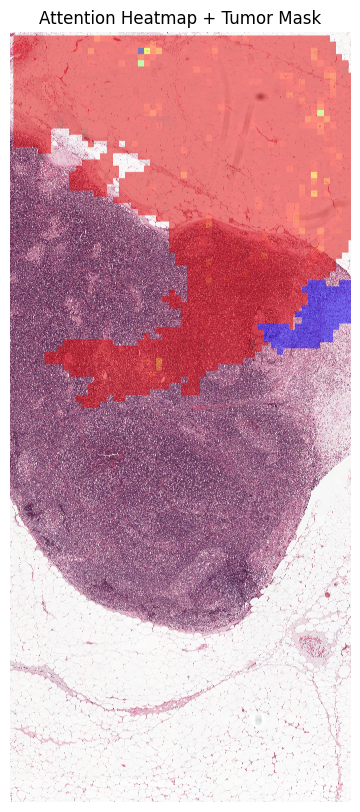

In [80]:
import openslide
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def show_attention_on_region(_base_img, coords_, coords_attn_, 
                             patch_size=256, level=0, alpha=0.5,
                             region=None,
                             _mask_arr=None, mask_level=8):  # <<< 新增参数
    # * -------------- 读取原图片对应region部分（level0） --------------
    
    heatmap = _base_img.copy()

    print("[INFO] Attn min:", attn_norm.min(), "max:", attn_norm.max(),"attn_norm shape",attn_norm.shape)
    
    for i, (x, y) in enumerate(coords_): # x,x+256,y,y+256对应原图在level0的一个小方块
        x = int(x)
        y=int(y)
        # print(x,y) # 56960 113280 ; 56960 113536
        if not (left <= x < right and top <= y < bottom):
            continue  # skip patches outside region
        rel_x = int(x - left)
        rel_y = int(y - top)
        # print("pt1", (rel_x, rel_y), "pt2", (rel_x + 256, rel_y + 256))
        # pt1 (144, 400) pt2 (400, 656)
        # pt1 (13968, 7568) pt2 (14224, 7824)
        color = plt.cm.jet(coords_attn_[(x,y)])[:3]
        color = tuple(int(255 * c) for c in color)
        # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
        cv2.rectangle(
            img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
            pt1=(rel_x, rel_y),                   # 左上角坐标
            pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
            color=color,                          # 矩形颜色（B, G, R）格式
            thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
        )

    # * -------------- 加载mask并绘制轮廓 --------------
    if _mask_arr is not None:
        
        print(f"[INFO] Partial mask shape: {_mask_arr.shape}, unique labels: {np.unique(_mask_arr)}")
        
        # 提取 tumor 区域并绘制边界（仅 label==2）
        tumor_mask = (_mask_arr == 2).astype(np.uint8)
        count = np.sum(tumor_mask == 1) # tumor的mask只存在于图片左上角
        temp = np.argwhere(tumor_mask == 1)
        print(f"Found {len(temp)} coordinates with value 1:")
        for t in temp:
            rel_x, rel_y = t[0]*256, t[1]*256

            color =  (0, 0, 255) # 绿色
            # 为每个 patch 用其 attention score 映射的颜色，画出对应的矩形区域，从而形成整个 attention heatmap 叠加图
            cv2.rectangle(
                img=heatmap,                          # 要画的图像（NumPy array，通常是 RGB）
                pt1=(rel_x, rel_y),                   # 左上角坐标
                pt2=(rel_x + 256, rel_y + 256), # 右下角坐标
                color=color,                          # 矩形颜色（B, G, R）格式
                thickness=-1                          # 填充整个矩形（如果是 2 表示边框宽度为 2）
            )
        
    blended = cv2.addWeighted(heatmap, alpha, base_img, 1 - alpha, 0)

                
    # ------------------------------------------------

    # show image
    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    plt.title("Attention Heatmap + Tumor Mask")
    plt.show()
    

show_attention_on_region(
    _base_img=base_img,
    coords_=coords,
    coords_attn_=coords_attn,
    _mask_arr=mask_arr)


In [ ]:
show_attention_on_region(
    svs_path="/u/jcai1/code/usefulxai/data/camelyon16/images/tumor_001.tif",
    coords_=coords,
    coords_attn_=coords_attn
) # 不能在全图上，全图太大了